In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
metallohydrolase = pd.read_csv('metallohydrolases/placer_output/placer_results.csv')
#serinehydrolase = pd.read_csv('serine_hydrolases/placer_output/placer_results.csv')
yang = pd.read_csv('yang_filterzyme/placer_output/placer_results.csv')
martinez = pd.read_csv('martinez/placer_output/placer_results.csv')

# Load activity data 
metallohydrolase_activity = pd.read_pickle('metallohydrolases/filterzyme_output/geometricfiltering/structural_features_final.pkl')
serinehydrolase_activity = pd.read_pickle('serine_hydrolases/filterzyme_output/geometricfiltering/structural_features_final.pkl')
yang_activity = pd.read_pickle('yang_filterzyme/filterzyme_output_yang_benchmark/geometricfiltering/structural_features_final.pkl')
martinez_activity = pd.read_pickle('martinez/filterzyme_output/geometricfiltering/structural_features_final.pkl')

n_ester = 30
martinez_activity['Activity'] = (
    martinez_activity['Nr of ester hydrolyzed'] > n_ester
)


def average_placer_results(df, df_activity):
    numeric_cols = df.select_dtypes(include=np.number).columns
    avg_df = df.groupby('entry_id')[numeric_cols].mean().reset_index()
    avg_df.drop(columns=['model_idx'], inplace=True)
    avg_df['Entry'] = avg_df['entry_id'].str.split('_0_chai').str[0]
    if 'activity' in df_activity.columns:
        df_activity.rename(columns={'activity': 'Activity'}, inplace=True)
    avg_df = avg_df.merge(df_activity[['Entry', 'Activity']], on='Entry', how='left')
    return avg_df

# metallohydrolases_avg = average_placer_results(metallohydrolase, metallohydrolase_activity)
# serinehydrolases_avg = average_placer_results(serinehydrolase)
yang_avg = average_placer_results(yang, yang_activity)
martinez_avg = average_placer_results(martinez, martinez_activity)

In [82]:
martinez_avg

,entry_id,fape,lddt,rmsd,kabsch,prmsd,plddt,plddt_pde,Entry,Activity
0,CalA_1_Napthyl_acetate_0_chai,1.445317,0.941709,3.616422,0.702624,3.678328,0.559457,0.615121,CalA_1_Napthyl_acetate,True
1,CalA_1_Napthyl_acetate_0_chai,1.445317,0.941709,3.616422,0.702624,3.678328,0.559457,0.615121,CalA_1_Napthyl_acetate,True
2,CalA_1_Napthyl_acetate_0_chai,1.445317,0.941709,3.616422,0.702624,3.678328,0.559457,0.615121,CalA_1_Napthyl_acetate,True
3,CalA_1_Napthyl_acetate_0_chai,1.445317,0.941709,3.616422,0.702624,3.678328,0.559457,0.615121,CalA_1_Napthyl_acetate,True
4,CalA_1_Napthyl_acetate_0_chai,1.445317,0.941709,3.616422,0.702624,3.678328,0.559457,0.615121,CalA_1_Napthyl_acetate,True
...,...,...,...,...,...,...,...,...,...,...
3397,EH9_Vinyl_propionate_0_chai,1.398484,0.951489,1.558557,0.669692,1.746199,0.917943,0.953886,EH9_Vinyl_propionate,True
3398,EH9_Vinyl_propionate_0_chai,1.398484,0.951489,1.558557,0.669692,1.746199,0.917943,0.953886,EH9_Vinyl_propionate,True
3399,EH9_Vinyl_propionate_0_chai,1.398484,0.951489,1.558557,0.669692,1.746199,0.917943,0.953886,EH9_Vinyl_propionate,True
3400,EH9_Vinyl_propionate_0_chai,1.398484,0.951489,1.558557,0.669692,1.746199,0.917943,0.953886,EH9_Vinyl_propionate,True


/tmp/ipykernel_3664911/3071898724.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_3664911/3071898724.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_3664911/3071898724.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_3664911/3071898724.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_3664911/307189872

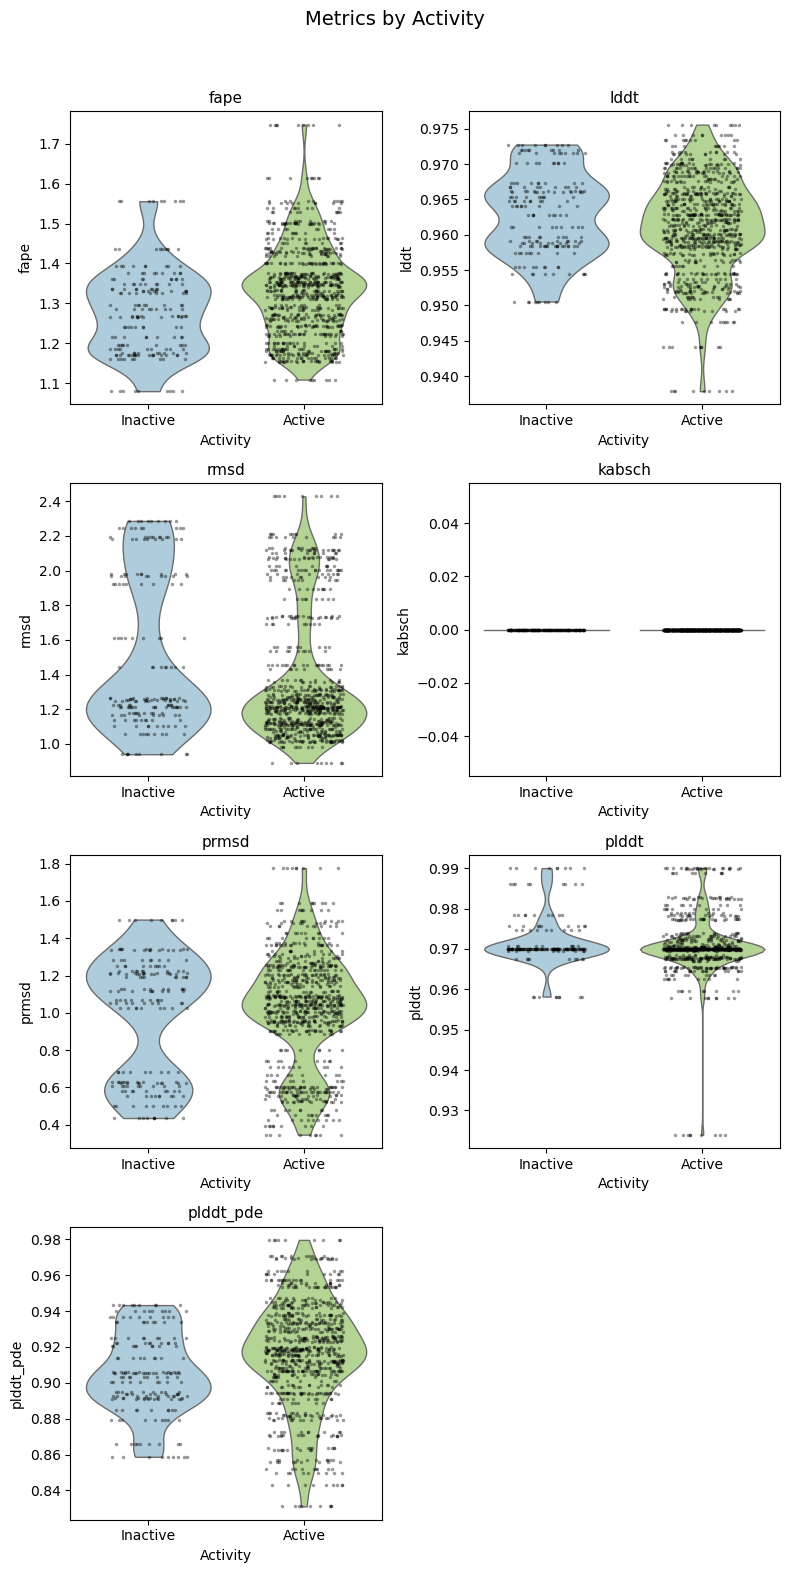

/tmp/ipykernel_3664911/3071898724.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_3664911/3071898724.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_3664911/3071898724.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_3664911/3071898724.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_3664911/307189872

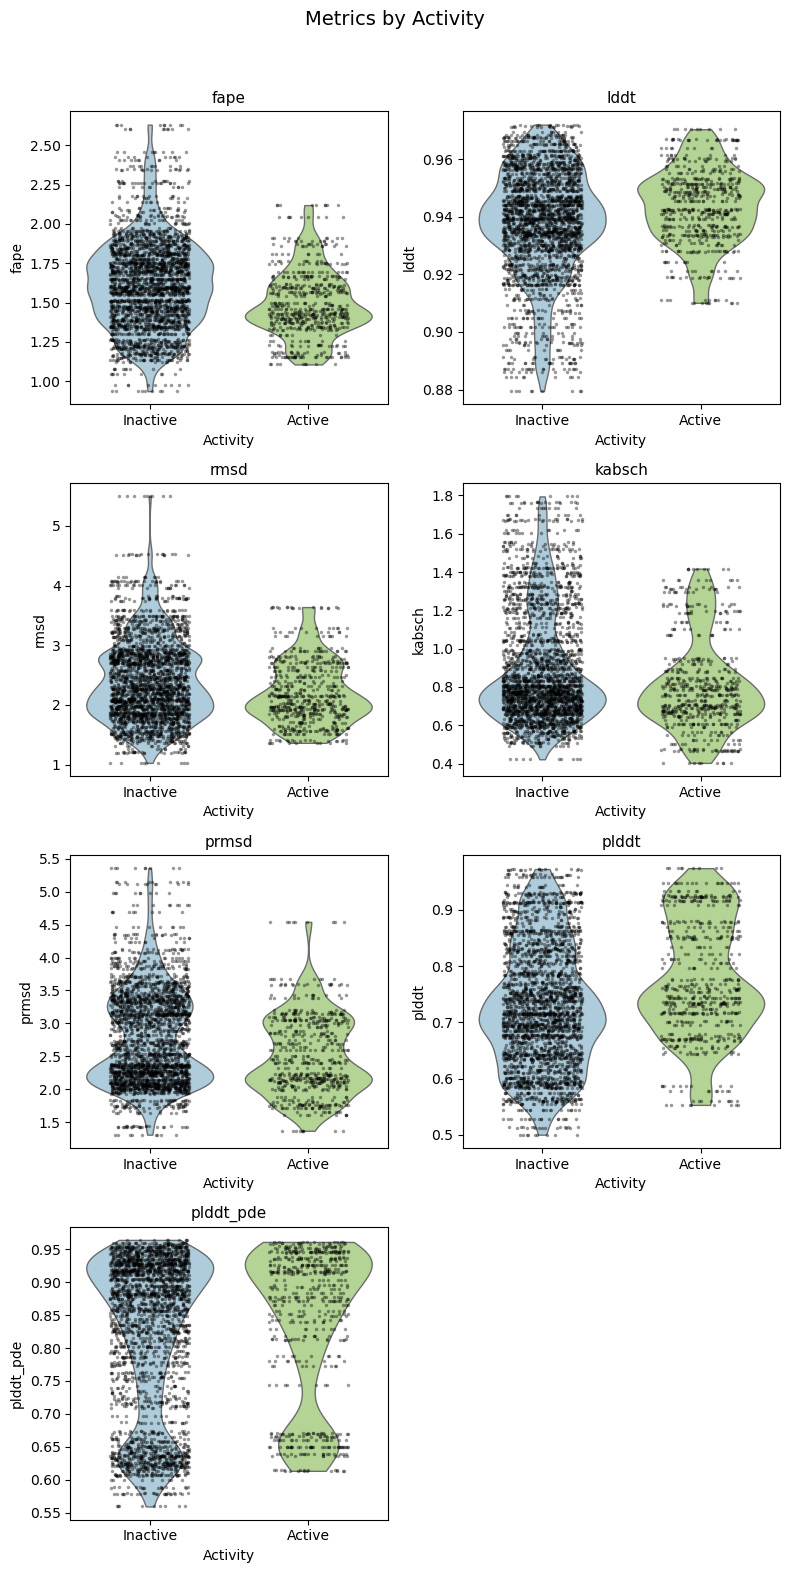

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def normalize_activity(series):
    mapping = {
        True: True, False: False,
        1: True, 0: False,
        "True": True, "False": False,
        "Y": True, "N": False,
        "Yes": True, "No": False,
    }
    return series.map(mapping)


def violin_grid_activity_x(
    df,
    activity_col='Activity',
    ncols=2,
    figsize_per_plot=(4, 4),
):
    if activity_col not in df.columns:
        raise ValueError(f"Column '{activity_col}' not found")

    # Copy to avoid side effects
    df = df.copy()

    # Normalize Activity to boolean, then convert to string labels
    df[activity_col] = normalize_activity(df[activity_col]).map({True: "Active", False: "Inactive"})

    if df[activity_col].isna().any():
        bad_vals = df.loc[df[activity_col].isna(), activity_col].unique()
        raise ValueError(f"Unmapped Activity values found: {bad_vals}")

    order = ["Inactive", "Active"]
    palette = {"Inactive": "#A6CEE3", "Active": "#B2DF8A"}

    # Numeric columns only
    numeric_cols = (
        df.select_dtypes(include='number')
          .columns
          .drop(activity_col, errors='ignore')
    )


    n_plots = len(numeric_cols)
    nrows = int(np.ceil(n_plots / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_per_plot[0] * ncols, figsize_per_plot[1] * nrows),
        squeeze=False
    )

    for ax, col in zip(axes.flat, numeric_cols):
        sns.violinplot(
            data=df,
            x=activity_col,
            y=col,
            order=order,
            palette=palette,
            inner=None,
            cut=0,
            linewidth=1,
            ax=ax
        )

        sns.stripplot(
            data=df,
            x=activity_col,
            y=col,
            order=order,
            color="black",
            size=2.5,
            alpha=0.4,
            jitter=0.25,
            ax=ax
        )

        ax.set_title(col, fontsize=11)
        ax.set_xlabel("Activity")
        ax.set_ylabel(col)

    # Remove unused axes
    for ax in axes.flat[n_plots:]:
        ax.remove()

    fig.suptitle("Metrics by Activity", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


violin_grid_activity_x(yang_avg)
violin_grid_activity_x(martinez_avg)